<a href="https://colab.research.google.com/github/natee-s/Car_counting/blob/main/Car_counting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step1: ติดตั้งไลบรารีที่จำเป็น

In [10]:
!pip install ultralytics opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.0 MB/s eta 0:00:00


## Step2: ดึงเฟรมแรกมาดูพิกัดเส้น
ก่อนจะให้โมเดลเริ่มนับ เราต้องรู้ก่อนว่าตำแหน่งเส้นกลางค่อนลงล่างที่คุณต้องการ อยู่ที่พิกัดแกน Y เท่าไหร่

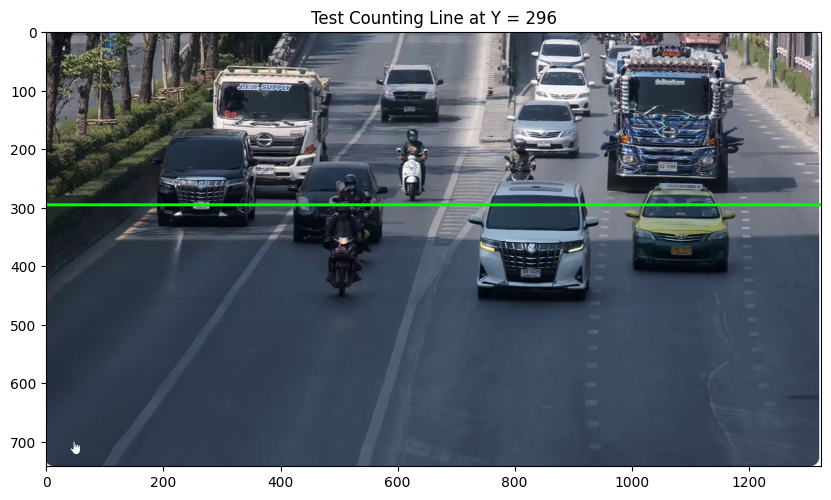

In [12]:
import cv2
import matplotlib.pyplot as plt

# ระบุชื่อไฟล์วิดีโอของคุณ
video_path = "test_video.mp4"

cap = cv2.VideoCapture(video_path)
ret, frame = cap.read()

if ret:
    # แปลงสีจาก BGR (OpenCV) เป็น RGB (Matplotlib) เพื่อให้สีตรงตามจริง
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # สมมติเส้นให้อยู่ที่ 60% ของความสูงภาพ
    height, width, _ = frame.shape
    line_y = int(height * 0.4)

    # วาดเส้นสีแดงเพื่อทดสอบดูตำแหน่ง
    cv2.line(frame_rgb, (0, line_y), (width, line_y), (0, 255, 0), 3)

    # แสดงภาพพร้อมแกน X, Y
    plt.figure(figsize=(10, 8))
    plt.imshow(frame_rgb)
    plt.title(f"Test Counting Line at Y = {line_y}")
    plt.show()
else:
    print("อ่านวิดีโอไม่ได้ กรุณาเช็กชื่อไฟล์ครับ")

cap.release()

## Step3: นำโมเดล YOLO มาตรวจจับ ติดตาม และนับรถ

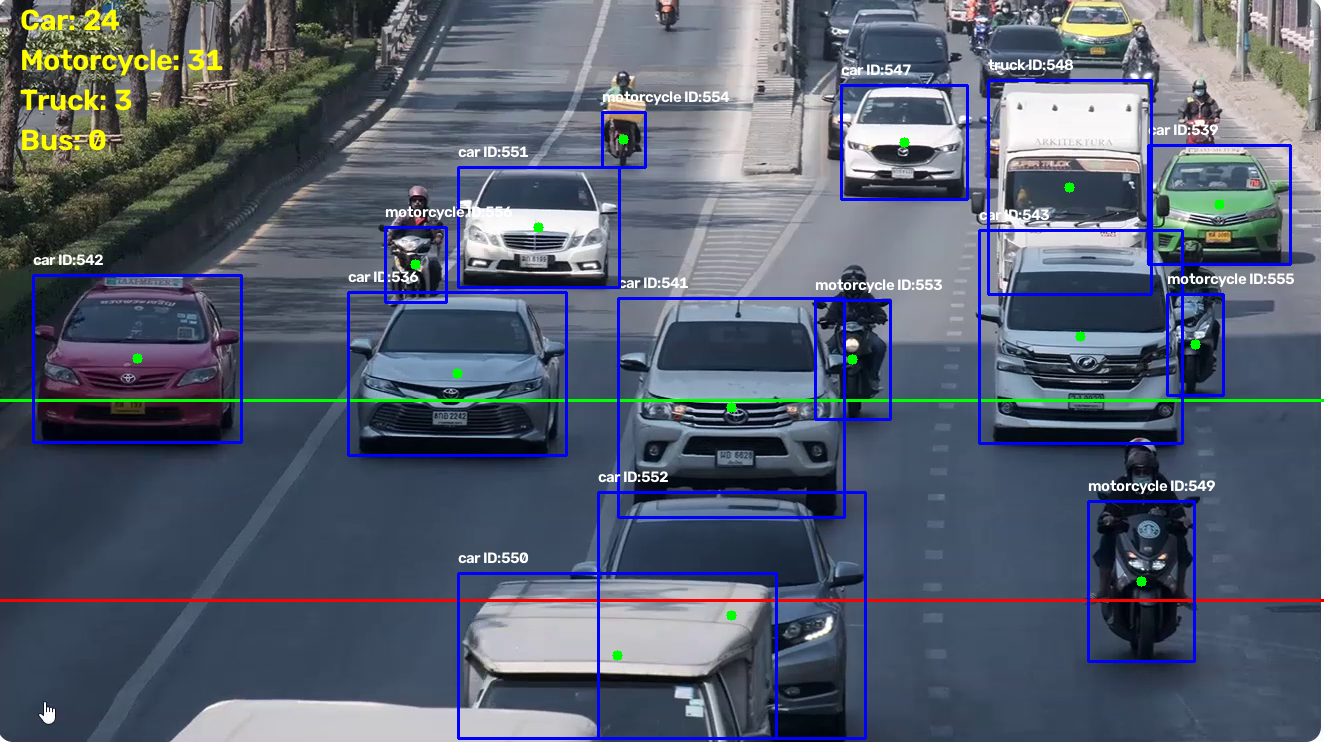

จบการประมวลผล! สามารถดาวน์โหลดวิดีโอผลลัพธ์ได้ที่ไฟล์: output_video.mp4


In [19]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

# [Model Initialization]
# โหลดโมเดล YOLOv8 ขนาด Small (yolov8s.pt) แทนรุ่น Nano (n)
# เหตุผล: จากการทดสอบพบว่ารุ่น Nano หลุดการตรวจจับมอเตอร์ไซค์ที่อยู่ไกลหรือสีกลืนกับถนน
# การขยับมาใช้รุ่น Small จะแลกความเร็วการรันนิดหน่อยแต่ได้ Feature Extraction ที่ลึกขึ้น (แม่นยำขึ้น)
model = YOLO("yolov8s.pt")

# [Video Setup]
# โหลดวิดีโอเพื่อเตรียมส่งเข้า Pipeline ทีละเฟรม
video_path = "test_video.mp4"
cap = cv2.VideoCapture(video_path)

# [Video Exporter Setup]
# การเซฟวิดีโอต้องจำลองสเปก (Width, Height, FPS) ให้ตรงกับต้นฉบับเป๊ะๆ
# ถ้าตั้งค่า Resolution ผิด cv2.VideoWriter จะเขียนไฟล์ออกมาเป็นไฟล์เปล่า (0 KB) หรือไฟล์เสียทันที
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# ใช้ FourCC 'mp4v' เป็น Codec มาตรฐานที่ทำงานร่วมกับนามสกุล .mp4 ได้เสถียรที่สุดใน OpenCV
output_path = "output_video.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# [Counting Zone Configuration]
# เปลี่ยนจาก "เส้นเดี่ยว" เป็น "โซน (Zone)" เพื่อแก้ปัญหารถวิ่งเร็วแล้วจุด Center Point กระโดดข้ามเส้น
# ทำให้รถตกหล่นไม่ถูกนับ ระยะห่าง 200 พิกเซล (400-600) เพียงพอต่อการดักจับรถในความเร็ววิดีโอปกติ
line1_y = 400 # Entry line (พิกัดเริ่มนับ)
line2_y = 600 # Exit line (พิกัดสิ้นสุดการดักจับ)

# [State Management]
# ใช้ Set data structure สำหรับ counted_ids เพราะทำ Lookup (เช็กว่ามี ID หรือยัง) ได้เร็วกว่า List (O(1) vs O(N))
# สำคัญมากสำหรับการประมวลผลวิดีโอแบบ Real-time ที่ต้องเช็กเงื่อนไขนี้ทุกๆ เฟรม
counted_ids = set()
counts = {"car": 0, "motorcycle": 0, "truck": 0, "bus": 0}

# [Class Filtering]
# อ้างอิงจาก COCO Dataset กำหนดให้โมเดลประมวลผลและส่งค่ากลับมาเฉพาะยานพาหนะเท่านั้น
# ช่วยลดภาระการประมวลผลของโมเดล (ไม่ให้ไปวอกแวกตรวจจับ คน ต้นไม้ หรือป้ายทะเบียน)
target_classes = [2, 3, 5, 7]
class_names = {2: "car", 3: "motorcycle", 5: "bus", 7: "truck"}

# [Main Processing Loop]
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break # จบวิดีโอ

    # [Object Tracking & Inference]
    # - ใช้ .track() (ByteTrack) แทน .predict() เพื่อผูก ID ให้กับวัตถุที่เคลื่อนที่ข้ามเฟรม
    # - conf=0.10: ลดเกณฑ์ความมั่นใจลงเพื่อดึงเอา Bounding box ของมอเตอร์ไซค์ไซส์เล็กๆ กลับมา
    # - iou=0.5: ปรับ Non-Maximum Suppression ป้องกันกรณีมอเตอร์ไซค์ขี่เบียดกันแล้วกล่องโดนรวบเป็นคันเดียว
    # - imgsz=640: บังคับอัปสเกลภาพก่อนป้อนเข้าเน็ตเวิร์ก ช่วยรักษา High-Frequency Details (ขอบ/รูปทรงของรถที่อยู่ไกล)
    results = model.track(frame, persist=True, classes=target_classes, verbose=False, conf=0.10, iou=0.5, imgsz=640)

    # เช็กว่าในเฟรมนี้โมเดลเจอวัตถุ (และ Assign ID ให้) หรือไม่
    if results[0].boxes.id is not None:
        # ย้ายข้อมูล Tensor จาก GPU (.cpu()) แล้วแปลงเป็น List เพื่อให้ OpenCV จัดการวาดได้ง่ายขึ้น
        boxes = results[0].boxes.xyxy.cpu()
        track_ids = results[0].boxes.id.int().cpu().tolist()
        class_ids = results[0].boxes.cls.int().cpu().tolist()

        # วาดโซนการนับลงบนเฟรม (Visual Debugging) ช่วยให้ตรวจสอบความถูกต้องของการตั้งค่าพิกัดได้ง่าย
        cv2.line(frame, (0, line1_y), (width, line1_y), (0, 255, 0), 2) # Entry
        cv2.line(frame, (0, line2_y), (width, line2_y), (0, 0, 255), 2) # Exit

        # วนลูปวาด Bounding Box และคำนวณ Logic สำหรับรถแต่ละคันที่เจอในเฟรมปัจจุบัน
        for box, track_id, class_id in zip(boxes, track_ids, class_ids):
            x1, y1, x2, y2 = map(int, box)

            # คำนวณหา Center Point เพื่อใช้เป็นตัวแทนของรถทั้งคันในการตัดผ่านโซนนับ
            # แม่นยำกว่าการใช้ขอบกล่อง (x1, y1) เพราะขอบกล่องอาจจะยืด/หดตามมุมกล้องได้
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            # วาด UI
            cv2.circle(frame, (cx, cy), 5, (0, 255, 0), -1)
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)

            # ดึงชื่อคลาส (ใช้ .get ป้องกัน KeyError หากโมเดลบั๊กหลุดคลาสอื่นมา)
            car_type = class_names.get(class_id, "unknown")
            label = f"{car_type} ID:{track_id}"
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

            # [Counting Logic]
            # เงื่อนไข: ถ้าจุดศูนย์กลางของรถร่วงเข้ามาอยู่ในโซน (ระหว่างบรรทัด 400 ถึง 600)
            # และ ID ของรถคันนี้ยังไม่เคยอยู่ใน Set (ป้องกันการบวกคะแนนซ้ำทุกๆ เฟรมที่รถยังแช่อยู่ในโซน)
            if line1_y < cy < line2_y and track_id not in counted_ids:
                counted_ids.add(track_id) # Cache ID ไว้
                if car_type in counts:
                    counts[car_type] += 1 # อัปเดต State การนับ

    # [Dashboard UI Rendering]
    # นำ State การนับปัจจุบัน (ตัวแปร counts) มาแปลงเป็นข้อความแปะทับลงไปที่มุมซ้ายบนของเฟรม
    y_offset = 30
    for car_type, count in counts.items():
        text = f"{car_type.capitalize()}: {count}"
        cv2.putText(frame, text, (20, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
        y_offset += 40

    # [Video Export]
    # เขียนเฟรมที่ถูกเติม UI และ Annotations เสร็จสมบูรณ์แล้ว กลับลงไปในไฟล์วิดีโอ
    out.write(frame)

    # [Colab Display Hack]
    # เคลียร์ Output เก่าของ Cell ทิ้งทันที แล้วแสดงเฟรมใหม่ขึ้นมาแทน
    # เป็น Workaround เพื่อจำลองการเล่นวิดีโอ (Video Streaming) ภายใน Jupyter/Colab Environment
    clear_output(wait=True)
    cv2_imshow(frame)

# [Resource Cleanup]
# ต้อง Release เสมอ ไม่เช่นนั้นไฟล์วิดีโอที่ Export ออกมาจะไม่ Finalize ทำให้ไฟล์เสีย และเปลือง Memory ของ OS
cap.release()
out.release()
print(f"จบการประมวลผล! สามารถดาวน์โหลดวิดีโอผลลัพธ์ได้ที่ไฟล์: {output_path}")